DATA SET setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

df = pd.read_csv("https://raw.githubusercontent.com/swapnilsaurav/Dataset/refs/heads/master/hotel_bookings.csv")
df.head()

,id,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,Resort Hotel,0.0,342.0,2015,July,27.0,1.0,0.0,0.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,0.0,Check-Out,01-07-2015
1,2,Resort Hotel,0.0,737.0,2015,July,27.0,1.0,0.0,0.0,...,No Deposit,NaN,NaN,0.0,Transient,0.0,0.0,10.0,Check-Out,01-07-2015
2,3,Resort Hotel,0.0,7.0,2015,July,27.0,1.0,0.0,1.0,...,No Deposit,NaN,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,02-07-2015
3,4,Resort Hotel,0.0,13.0,2015,July,27.0,1.0,0.0,1.0,...,No Deposit,304.0,NaN,0.0,Transient,75.0,0.0,0.0,Check-Out,02-07-2015
4,5,Resort Hotel,0.0,14.0,2015,July,27.0,1.0,0.0,2.0,...,No Deposit,240.0,NaN,0.0,Transient,98.0,0.0,1.0,Check-Out,03-07-2015


TASK-1

In [15]:
# Target
# Drop rows where 'is_canceled' is NaN before proceeding
df.dropna(subset=['is_canceled'], inplace=True)
y = df['is_canceled']
X = df.drop(columns=['is_canceled'])

# Column types
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Pipelines
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean"))
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

model = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, solver='liblinear')) # Added solver for robustness
])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Added random_state and stratify for reproducibility

# Train
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9960211090634947
ROC-AUC: 0.9999456784977149
Confusion Matrix:
 [[15024     7]
 [   88  8757]]


TASK-2

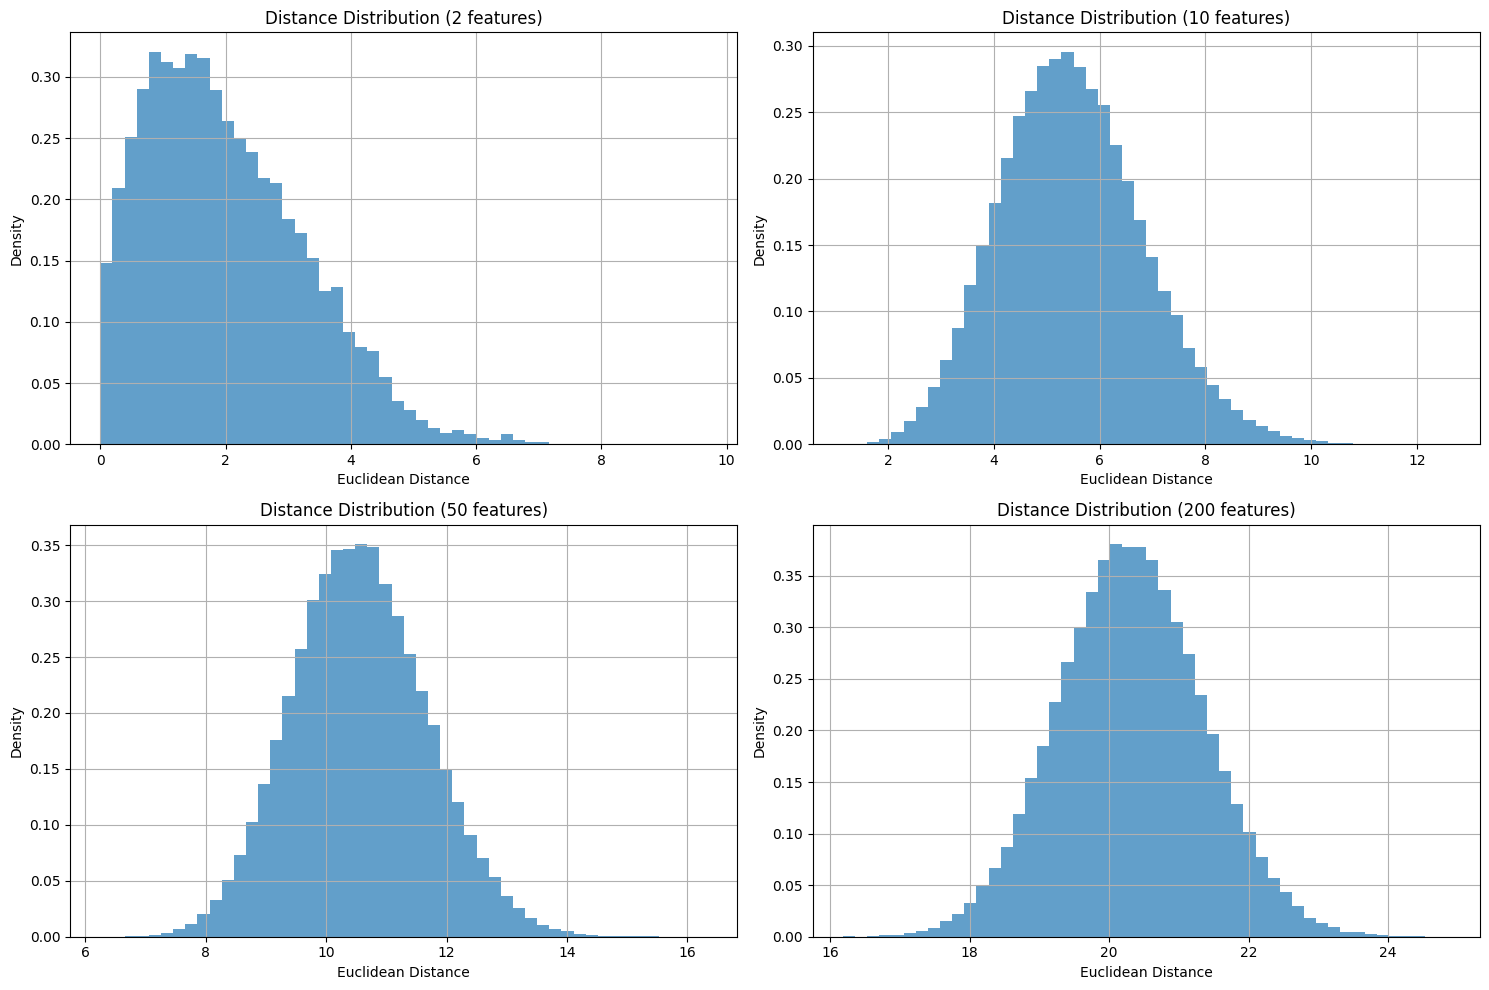

In [24]:
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

dims = [2, 10, 50, 200]

plt.figure(figsize=(15, 10))

for i, d in enumerate(dims):
    # For low dimensions, sometimes make_classification can struggle with default parameters.
    # Adjust n_informative and n_classes for d=2 to ensure proper data generation.
    if d == 2:
        X_syn, _ = make_classification(
            n_samples=500,
            n_features=d,
            n_informative=d, # n_informative should be <= n_features
            n_redundant=0,
            n_repeated=0,
            n_classes=2,
            n_clusters_per_class=1,
            random_state=42
        )
    else:
        X_syn, _ = make_classification(
            n_samples=500,
            n_features=d,
            n_informative=min(d, 5), # Keep n_informative reasonable for higher dimensions
            n_redundant=0,
            n_repeated=0,
            n_classes=2,
            n_clusters_per_class=2,
            random_state=42
        )

    # Calculate pairwise Euclidean distances
    dist = pdist(X_syn, metric='euclidean')

    plt.subplot(2, 2, i + 1)
    plt.hist(dist, bins=50, density=True, alpha=0.7)
    plt.title(f'Distance Distribution ({d} features)')
    plt.xlabel('Euclidean Distance')
    plt.ylabel('Density')
    plt.grid(True)

plt.tight_layout()
plt.show()

TASK-3

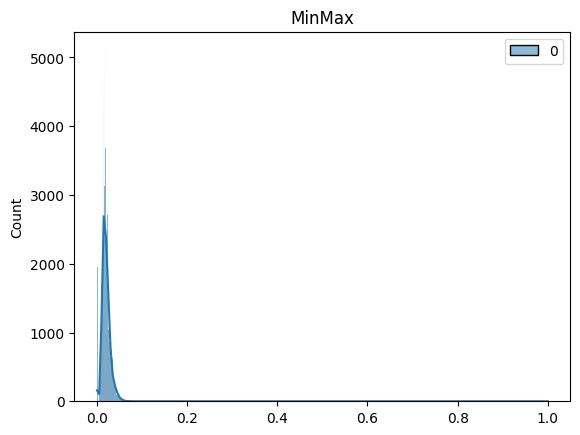

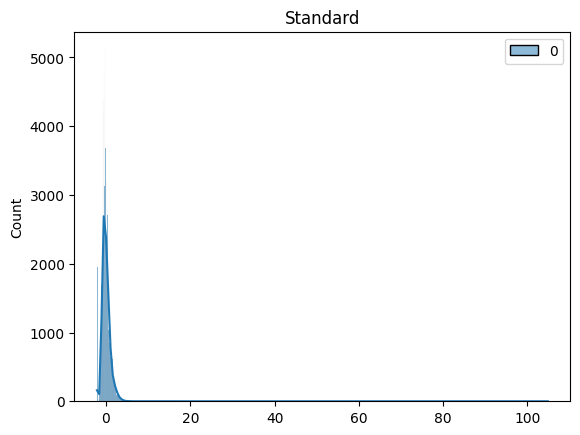

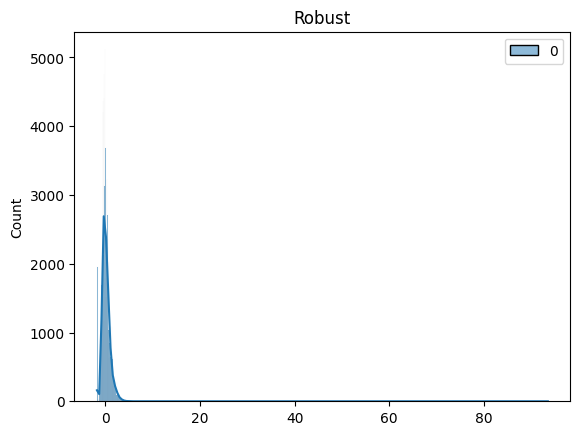

In [32]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import seaborn as sns

# Select numeric columns safely
num_features = ['lead_time','adr','stays_in_week_nights',
                'stays_in_weekend_nights','adults','children']

df_num = df[num_features].copy()

# Binning
df['adr_bin'] = pd.qcut(df['adr'], q=4, duplicates='drop')
df['lead_time_bin'] = pd.cut(df['lead_time'], bins=5)

# Binarization
df['high_value_customer'] = (df['adr'] > df['adr'].median()).astype(int)

# Scaling comparison
scalers = {
    "MinMax": MinMaxScaler(),
    "Standard": StandardScaler(),
    "Robust": RobustScaler()
}

for name, scaler in scalers.items():
    scaled = scaler.fit_transform(df_num[['adr']])
    sns.histplot(scaled, kde=True)
    plt.title(name)
    plt.show()

TASK-4

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Only numeric data
X_knn = df[num_features].fillna(0)
y_knn = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

# No scaling
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print("No Scaling:", knn.score(X_test, y_test))

# With scaling
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(metric='euclidean'))
])
pipe.fit(X_train, y_train)
print("With StandardScaler:", pipe.score(X_test, y_test))

# Manhattan
pipe2 = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(metric='manhattan'))
])
pipe2.fit(X_train, y_train)
print("Manhattan:", pipe2.score(X_test, y_test))

No Scaling: 0.7576646004355838
With StandardScaler: 0.7630256324342436
Manhattan: 0.7626068018093483


TASK-5

In [37]:
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import cross_val_score

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("power", PowerTransformer()),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

scores = cross_val_score(pipeline, X, y, cv=5, scoring='roc_auc')
print("CV ROC-AUC:", scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:3475: RuntimeWarning: overflow encountered in power
  out[pos] = (np.power(x[pos] + 1, lmbda) - 1) / lmbda
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:3475: RuntimeWarning: overflow encountered in power
  out[pos] = (np.power(x[pos] + 1, lmbda) - 1) / lmbda
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:3475: RuntimeWarning: overflow encountered in power
  out[pos] = (np.power(x[pos] + 1, lmbda) - 1) / lmbda
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:3475: RuntimeWarning: overflow encountered in power
  out[pos] = (np.power(x[pos] + 1, lmbda) - 1) / lmbda
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:199: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(x, axis

CV ROC-AUC: nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
4 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_

TASK-6

In [38]:
df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    errors='coerce'
)

df['month'] = df['arrival_date'].dt.month
df['weekday'] = df['arrival_date'].dt.weekday
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

/tmp/ipykernel_1603/3582483578.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['arrival_date'] = pd.to_datetime(


TASK-7

In [41]:


# Ensure required columns exist
df['children'] = df['children'].fillna(0)
df['babies'] = df['babies'].fillna(0)
df['adr'] = df['adr'].fillna(0)
df['lead_time'] = df['lead_time'].fillna(0)
df['total_of_special_requests'] = df['total_of_special_requests'].fillna(0)
df['hotel'] = df['hotel'].fillna('Unknown')

# Total guests (avoid zero)
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_guests'] = df['total_guests'].replace(0, 1)

# Total nights (IMPORTANT — missing in your error)
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']

# Avoid zero nights
df['total_nights'] = df['total_nights'].replace(0, 1)


# --- FEATURE CONSTRUCTION ---

# Ratio features
df['price_per_person'] = df['adr'] / df['total_guests']
df['requests_per_night'] = df['total_of_special_requests'] / df['total_nights']

# Interaction features
df['adr_lead'] = df['adr'] * df['lead_time']
df['guests_nights'] = df['total_guests'] * df['total_nights']

# Binary feature
df['is_family'] = ((df['children'] + df['babies']) > 0).astype(int)

# Aggregation feature (SAFE)
df['avg_adr_by_hotel'] = df.groupby('hotel')['adr'].transform('mean')

# Polynomial features (safe version)
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df[['adr', 'lead_time']])



TASK-8

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif

X_model = df[num_features].fillna(0)
y_model = df['is_canceled']

rf = RandomForestClassifier(random_state=42)
rf.fit(X_model, y_model)

print(pd.Series(rf.feature_importances_, index=num_features).sort_values(ascending=False))

mi = mutual_info_classif(X_model, y_model)
print(pd.Series(mi, index=num_features).sort_values(ascending=False))

lead_time                  0.442342
adr                        0.437305
stays_in_week_nights       0.059668
stays_in_weekend_nights    0.028470
adults                     0.020699
children                   0.011517
dtype: float64
lead_time                  0.080023
adr                        0.078381
stays_in_week_nights       0.012632
adults                     0.011337
stays_in_weekend_nights    0.005762
children                   0.001703
dtype: float64
